In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the dataset

old_df = pd.read_csv('../Randomized_data.csv', parse_dates = True, index_col=0)  


In [6]:
def clean_data(df):    
    # cleaning data by exracting reading that were averaged over 1sec
    # Calculate the time delta between consecutive rows
    df['delta'] = df.index.to_series().diff()

    # Create a mask for rows where the time delta is greater than 1 second
    mask = df['delta'] > pd.Timedelta(seconds=2)

    specific_datetime = df.index[mask]

    # timesteps to go backwards
    time_steps = df['delta'][mask] - pd.Timedelta(seconds=2)

    # Initialize a list to accumulate new rows
    new_rows_list = []

    # Loop through each specific datetime and corresponding time step
    for dt, step in zip(specific_datetime, time_steps):
        start = dt - step
        end = dt - pd.Timedelta(seconds=1)

        # Generate a date range with the new rows
        date_range = pd.date_range(start=start, end=end, freq='s')

        # Create DataFrame with new rows
        new_rows = pd.DataFrame(index=date_range, columns=df.columns)

        # Append new rows to the list
        new_rows_list.append(new_rows)

    if (len(new_rows_list) > 0):
        # Concatenate all new rows and append them to the original DataFrame
        new_rows_combined = pd.concat(new_rows_list)
        df = pd.concat([df, new_rows_combined])

    # Sort the DataFrame by index
    df = df.sort_index()

    #########


    # Calculate the time delta between consecutive rows
    df['delta'] = df.index.to_series().diff()

    # Create a mask for rows where the time delta is greater than 1 second
    mask = df['delta'] > pd.Timedelta(seconds=1)

    # keep 3 rows preceding them
    rows_to_keep = df.index[mask].to_series().index - pd.Timedelta(seconds=3)

    return df.loc[rows_to_keep]

In [7]:
df_t1 = pd.read_csv('31-10-2024_17-49-00_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
df_s1 = pd.read_csv('31-10-2024_18-28-05_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data

df_t2 = pd.read_csv('31-10-2024_17-06-00_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
df_s2 = pd.read_csv('31-10-2024_17-36-01_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data

df_t3 = pd.read_csv('01-11-2024_13-49-55_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
df_s3 = pd.read_csv('01-11-2024_14-23-35_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data

df_t4 = pd.read_csv('01-11-2024_14-28-11_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
df_s4 = pd.read_csv('01-11-2024_15-15-38_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data

df_t5 = pd.read_csv('01-11-2024_15-26-43_Coil_table_data_2.csv', parse_dates = True, index_col=0)  # coil table data
df_s5 = pd.read_csv('01-11-2024_15-55-43_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data

df_t6 = pd.read_csv('01-11-2024_16-29-23_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
df_s6 = pd.read_csv('01-11-2024_16-45-39_Mangnetometer_sensor_data.csv', parse_dates = True, date_format="%d-%m-%Y_%H-%M-%S", index_col=0 )  #  sensor data




# converting index to datetime index
df_t1.index = pd.to_datetime(df_t1.index, format="%d-%m-%Y_%H-%M-%S")
df_s1.index = pd.to_datetime(df_s1.index)

df_t2.index = pd.to_datetime(df_t2.index, format="%d-%m-%Y_%H-%M-%S")
df_s2.index = pd.to_datetime(df_s2.index)

df_t3.index = pd.to_datetime(df_t3.index, format="%d-%m-%Y_%H-%M-%S")
df_s3.index = pd.to_datetime(df_s3.index)

df_t4.index = pd.to_datetime(df_t4.index, format="%d-%m-%Y_%H-%M-%S")
df_s4.index = pd.to_datetime(df_s4.index)

df_t5.index = pd.to_datetime(df_t5.index, format="%d-%m-%Y_%H-%M-%S")
df_s5.index = pd.to_datetime(df_s5.index)

df_t6.index = pd.to_datetime(df_t6.index, format="%d-%m-%Y_%H-%M-%S")
df_s6.index = pd.to_datetime(df_s6.index)

# removing redundunt columns
df_t1.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15'], inplace=True)
df_t2.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15', 'Unnamed: 89'], inplace=True)
df_t3.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15'], inplace=True)
df_t4.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15'], inplace=True)
df_t5.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15'], inplace=True)
df_t6.drop(columns=['EEpose_0',	'EEpose_1',	'EEpose_2',	'EEpose_3',	'EEpose_4',	'EEpose_5',	'EEpose_6',	'EEpose_7',	'EEpose_8',	'EEpose_9',	'EEpose_10', 'EEpose_11', 'EEpose_12',	'EEpose_13', 'EEpose_14', 'EEpose_15'], inplace=True)

# resampling the data for 1sec freq
df_t1 = df_t1.resample('s').mean()
df_s1 = df_s1.resample('s').mean()

df_t2 = df_t2.resample('s').mean()
df_s2 = df_s2.resample('s').mean()

df_t3 = df_t3.resample('s').mean()
df_s3 = df_s3.resample('s').mean()

df_t4 = df_t4.resample('s').mean()
df_s4 = df_s4.resample('s').mean()

df_t5 = df_t5.resample('s').mean()
df_s5 = df_s5.resample('s').mean()

df_t6 = df_t6.resample('s').mean()
df_s6 = df_s6.resample('s').mean()


df_t1 = df_t1.dropna()
df_t2 = df_t2.dropna()
df_t3 = df_t3.dropna()
df_t4 = df_t4.dropna()
df_t5 = df_t5.dropna()
df_t6 = df_t6.dropna()


# join the sensor and table dataframes
df1 = df_t1.join(df_s1, how="inner")  # intersecion of the two dataframes
df2 = df_t2.join(df_s2, how="inner")  # intersecion of the two dataframes
df3 = df_t3.join(df_s3, how="inner")  # intersecion of the two dataframes
df4 = df_t4.join(df_s4, how="inner")  # intersecion of the two dataframes
df5 = df_t5.join(df_s5, how="inner")  # intersecion of the two dataframes
df6 = df_t6.join(df_s6, how="inner")  # intersecion of the two dataframes

#print(df1.head(5))

df1 = clean_data(df1)
df2 = clean_data(df2)
df3 = clean_data(df3)
df4 = clean_data(df4)
df5 = clean_data(df5)
df6 = clean_data(df6)

df = pd.concat([df1,df2,df3,df4,df5,df6])


C:\Users\Gediy\AppData\Local\Temp\ipykernel_14964\1608659463.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_t1 = pd.read_csv('31-10-2024_17-49-00_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
C:\Users\Gediy\AppData\Local\Temp\ipykernel_14964\1608659463.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_t2 = pd.read_csv('31-10-2024_17-06-00_Coil_table_data.csv', parse_dates = True, index_col=0)  # coil table data
C:\Users\Gediy\AppData\Local\Temp\ipykernel_14964\1608659463.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_t3 = pd.

In [8]:
# loading single coil current measurement data
C1 = pd.read_csv('../../Processed_data/coil1_data.csv', parse_dates = True, index_col=0)  #  Coil data
C2 = pd.read_csv('../../Processed_data/coil2_data.csv', parse_dates = True, index_col=0)  #  Coil data
C3 = pd.read_csv('../../Processed_data/coil3_data.csv', parse_dates = True, index_col=0)  #  Coil data
C4 = pd.read_csv('../../Processed_data/coil4_data.csv', parse_dates = True, index_col=0)  #  Coil data
C5 = pd.read_csv('../../Processed_data/coil5_data.csv', parse_dates = True, index_col=0)  #  Coil data
C6 = pd.read_csv('../../Processed_data/coil6_data.csv', parse_dates = True, index_col=0)  #  Coil data
C7 = pd.read_csv('../../Processed_data/coil7_data.csv', parse_dates = True, index_col=0)  #  Coil data
C8 = pd.read_csv('../../Processed_data/coil8_data.csv', parse_dates = True, index_col=0)  #  Coil data

singleCoil_measurement = [C1, C2, C3, C4, C5, C6, C7, C8]

def clean_scm(list):
    """
    removes 15A and -15A command current
    """
    updated_list = []
    for index,item in enumerate(list):
        item = item[item[f'cmdCoilCurrent_{index+1}(A)'] != 15]
        item = item[item[f'cmdCoilCurrent_{index+1}(A)'] != -15]
        updated_list.append(item)
        
    return updated_list

cleaned_scm = clean_scm(singleCoil_measurement)
    
df_scm = pd.concat(cleaned_scm)


In [9]:
#save data
df_new = pd.concat([old_df,df,df_scm])
# df_new.to_csv('Randomized_data_with_single_coil_measurement_Nov_22.csv', index=True)  # index=True to include datetime index

In [10]:
# Create an empty DataFrame
concatenated_df = pd.DataFrame()


for i in range(1, 17):
    # isolating data for  each sensor
    df_s = df_new[['cmdCoilCurrent_1(A)','cmdCoilCurrent_2(A)','cmdCoilCurrent_3(A)','cmdCoilCurrent_4(A)',
                      'cmdCoilCurrent_5(A)','cmdCoilCurrent_6(A)','cmdCoilCurrent_7(A)','cmdCoilCurrent_8(A)', 
                      f'Sensor_{i}_dir_x', f'Sensor_{i}_dir_y', f'Sensor_{i}_dir_z', 
                      f'sensor_{i}_X [mT]', f'sensor_{i}_Y [mT]', f'sensor_{i}_Z [mT]']]
    
    # Reset index to remove duplicates and change the column names
    df_s = df_s.reset_index(drop=True)
    df_s.columns = ['cmdCoilCurrent_1(A)','cmdCoilCurrent_2(A)','cmdCoilCurrent_3(A)','cmdCoilCurrent_4(A)',
                      'cmdCoilCurrent_5(A)','cmdCoilCurrent_6(A)','cmdCoilCurrent_7(A)','cmdCoilCurrent_8(A)', 
                      'x', 'y','z', 
                      'U', 'V', 'W']
    # concatenating
    concatenated_df = pd.concat([concatenated_df, df_s],ignore_index=True)

In [10]:
# Save the concatenated DataFrame to a CSV file
concatenated_df.to_csv('Processed_Randomized_data_with_single_coil_measurements_Nov_22.csv', index=True)  # index=True to include datetime index

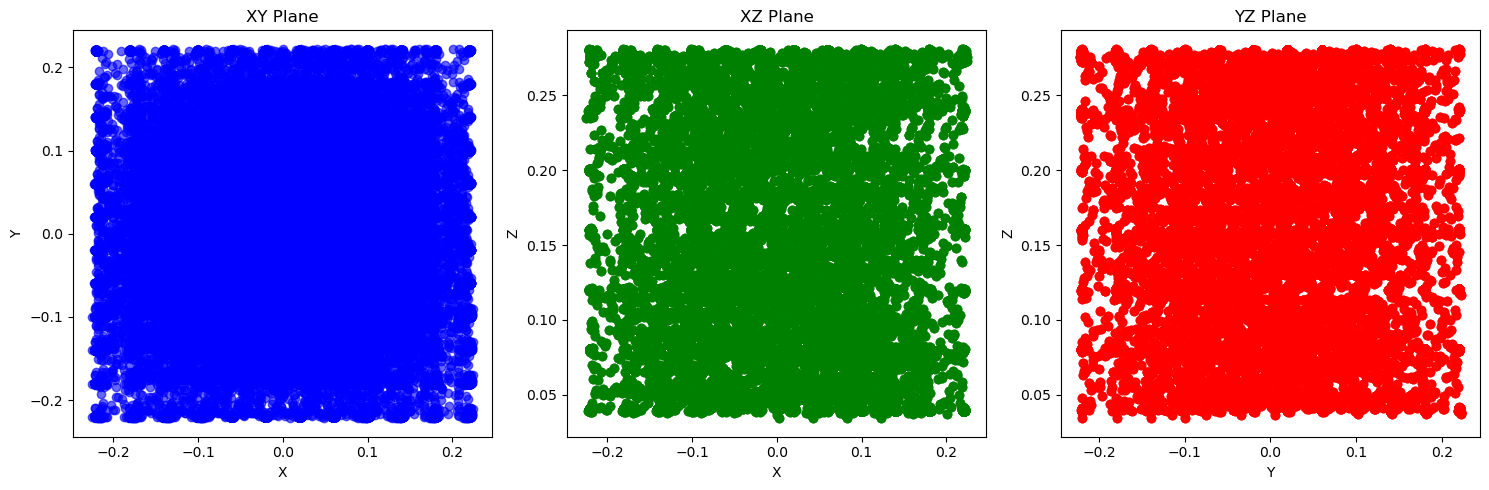

In [28]:
# 2D Projections
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# XY Plane
ax[0].scatter(concatenated_df['x'], concatenated_df['y'], c='blue', alpha=0.6)
ax[0].set_title("XY Plane")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

# XZ Plane
ax[1].scatter(concatenated_df['x'], concatenated_df['z'], c='green', alpha=0.6)
ax[1].set_title("XZ Plane")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Z")

# YZ Plane
ax[2].scatter(concatenated_df['y'], concatenated_df['z'], c='red', alpha=0.6)
ax[2].set_title("YZ Plane")
ax[2].set_xlabel("Y")
ax[2].set_ylabel("Z")

plt.tight_layout()
plt.show()

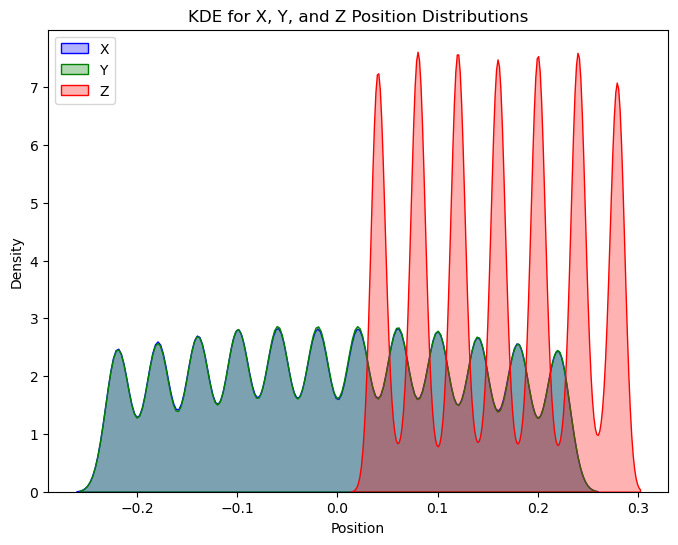

In [29]:
import seaborn as sns

# KDE plots for x, y, z
plt.figure(figsize=(8, 6))
sns.kdeplot(concatenated_df['x'], color='blue', label='X', fill=True, alpha=0.3)
sns.kdeplot(concatenated_df['y'], color='green', label='Y', fill=True, alpha=0.3)
sns.kdeplot(concatenated_df['z'], color='red', label='Z', fill=True, alpha=0.3)

plt.title("KDE for X, Y, and Z Position Distributions")
plt.xlabel("Position")
plt.ylabel("Density")
plt.legend()
plt.show()

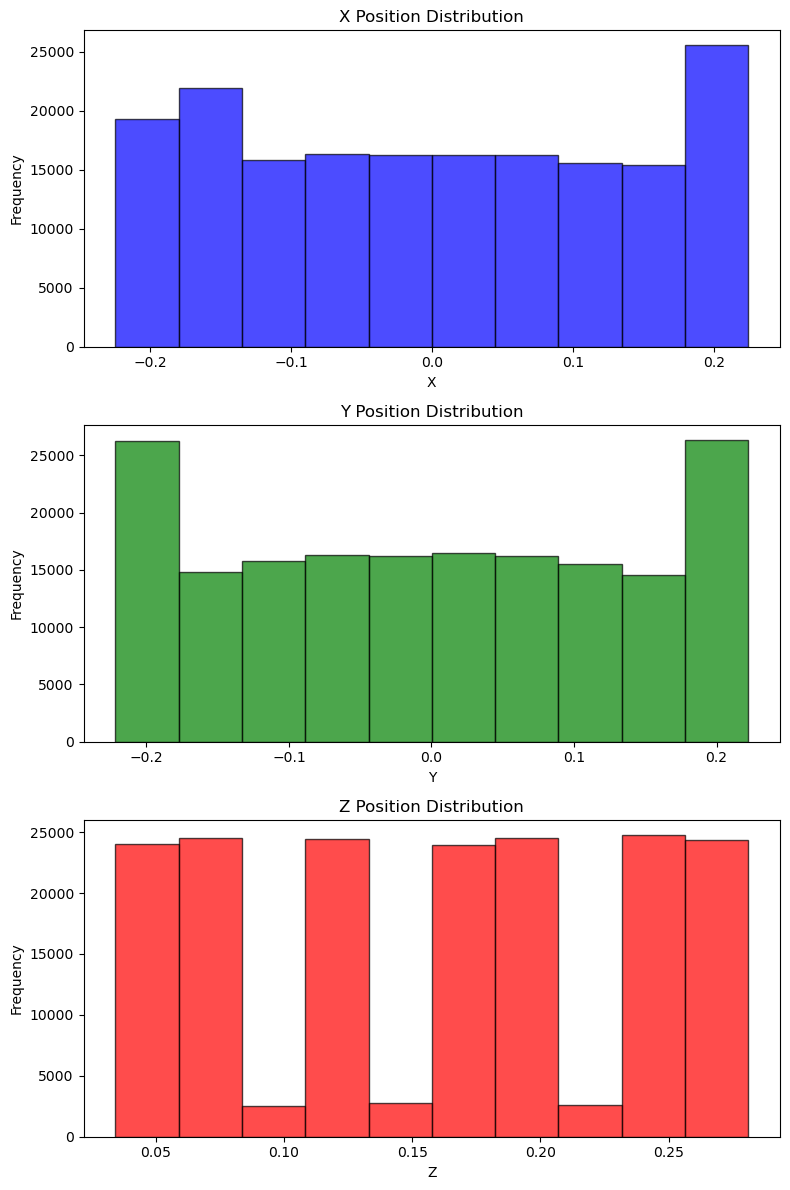

In [39]:
# Plot histograms for x, y, z
fig, ax = plt.subplots(3, 1, figsize=(8, 12))

ax[0].hist(concatenated_df['x'], bins=10, color='blue', alpha=0.7, edgecolor='black')
ax[0].set_title('X Position Distribution')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Frequency')

ax[1].hist(concatenated_df['y'], bins=10, color='green', alpha=0.7, edgecolor='black')
ax[1].set_title('Y Position Distribution')
ax[1].set_xlabel('Y')
ax[1].set_ylabel('Frequency')

ax[2].hist(concatenated_df['z'], bins=10, color='red', alpha=0.7, edgecolor='black')
ax[2].set_title('Z Position Distribution')
ax[2].set_xlabel('Z')
ax[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

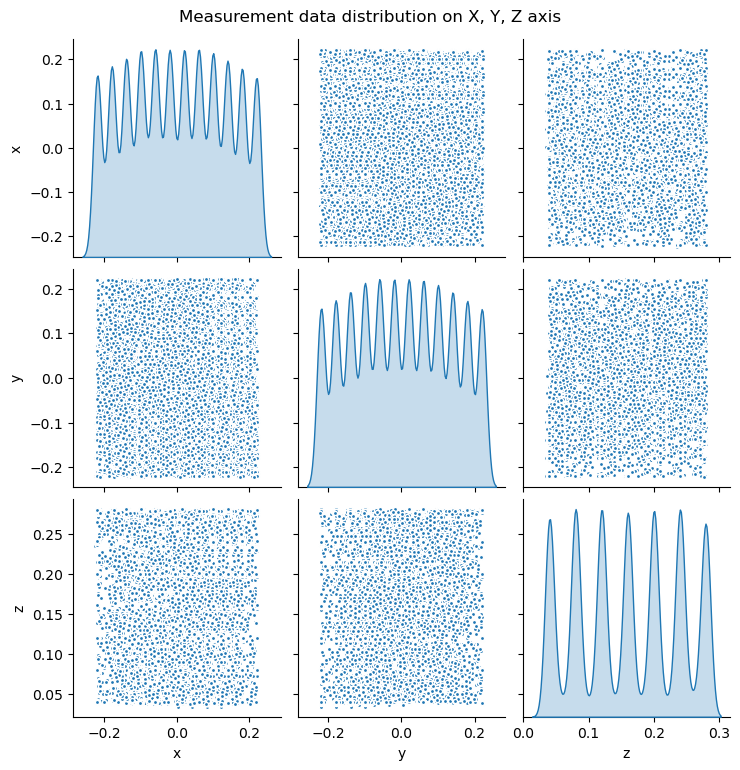

In [46]:
sns.pairplot(concatenated_df[['x','y','z']], kind="scatter",plot_kws=dict(marker=".", linewidth=1), diag_kind="kde")
plt.suptitle("Measurement data distribution on X, Y, Z axis", y=1.02)
plt.show()

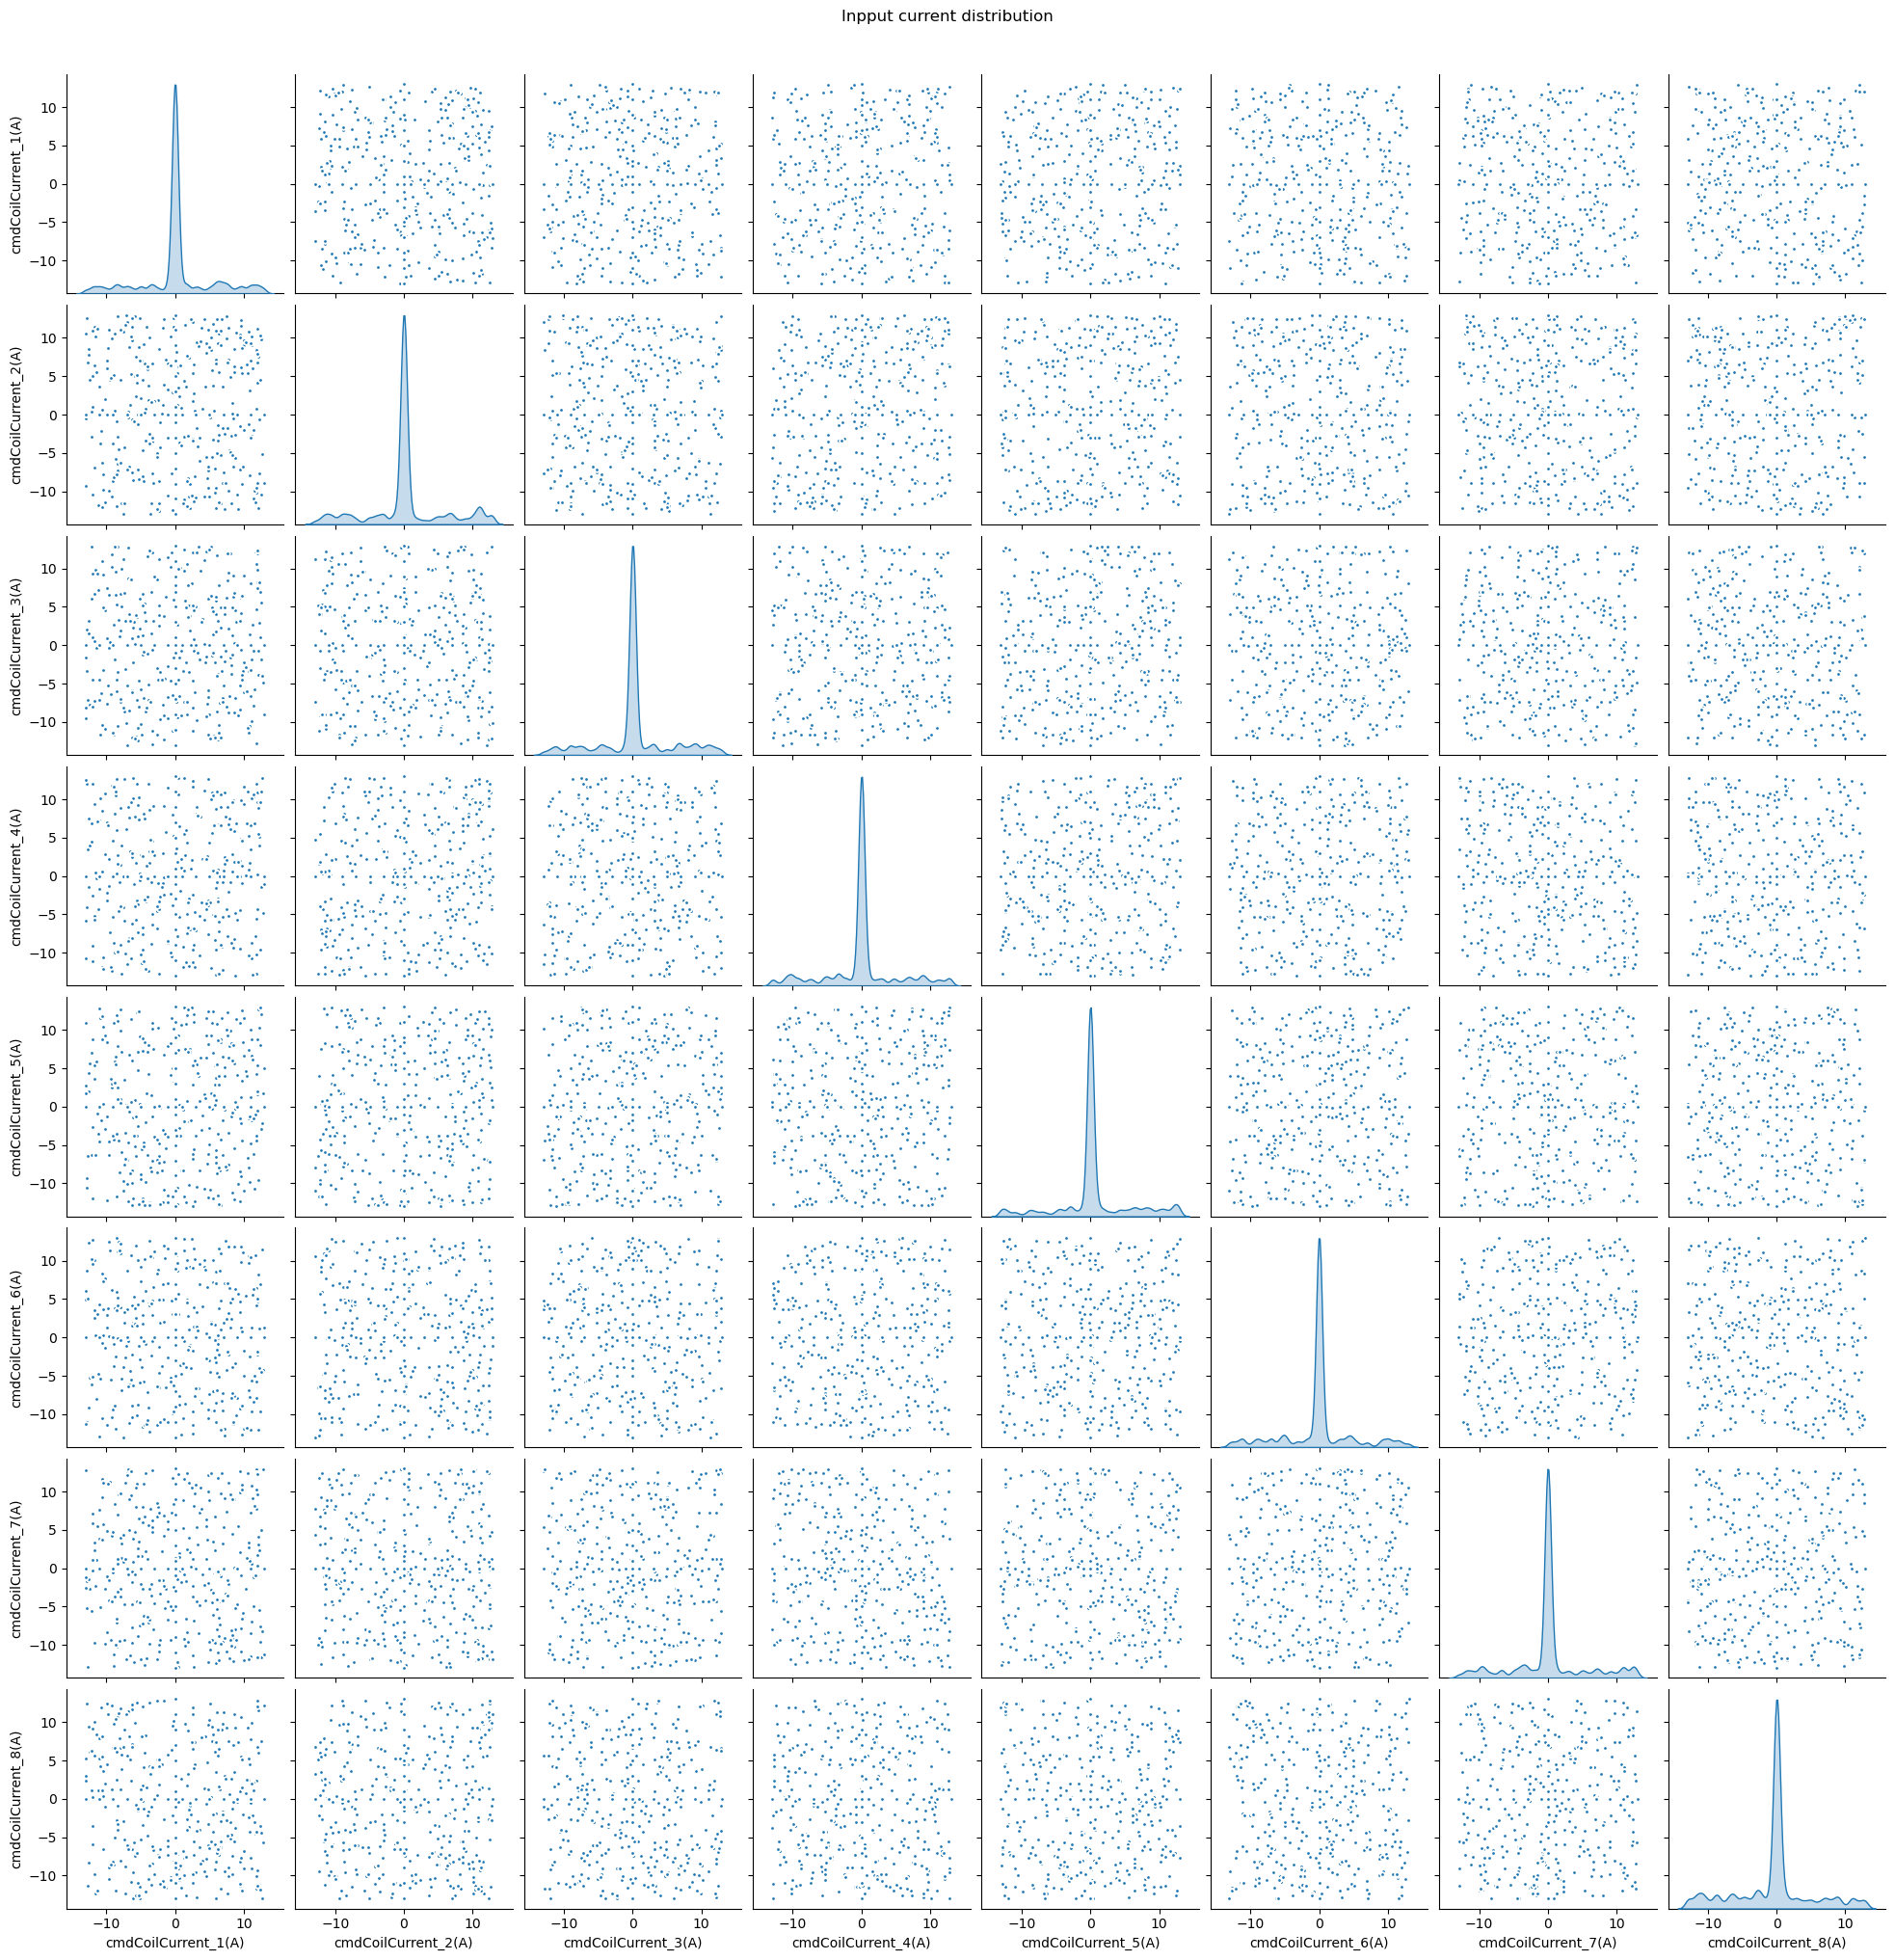

In [13]:
sns.pairplot(concatenated_df[['cmdCoilCurrent_1(A)','cmdCoilCurrent_2(A)','cmdCoilCurrent_3(A)','cmdCoilCurrent_4(A)',
                      'cmdCoilCurrent_5(A)','cmdCoilCurrent_6(A)','cmdCoilCurrent_7(A)','cmdCoilCurrent_8(A)']], kind="scatter",plot_kws=dict(marker=".", linewidth=1), diag_kind="kde")
plt.suptitle("Inpput current distribution", y=1.02)
plt.show()

In [54]:
import plotly.figure_factory as ff
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# Generate KDE data
x = concatenated_df['x'].dropna()
y = concatenated_df['y'].dropna()
z = concatenated_df['z'].dropna()

# Calculate KDE
xyz = np.vstack([x, y, z])
kde = gaussian_kde(xyz)

# Define grid for density estimation
x_grid, y_grid, z_grid = np.linspace(-0.22, 0.22, 30), np.linspace(-0.22, 0.22, 30), np.linspace(0, 0.28, 30)
X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
positions = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
density = kde(positions).reshape(X.shape)

# Visualize in Plotly
fig = go.Figure(data=go.Volume(
    x=X.ravel(),
    y=Y.ravel(),
    z=Z.ravel(),
    value=density.ravel(),
    isomin=0.01,
    isomax=np.max(density),
    opacity=0.1,  # Adjust for transparency
    surface_count=15,  # Number of density surfaces
    colorscale='Viridis',
))

fig.update_layout(
    title="3D Density Plot of Position Distribution",
    scene=dict(
        xaxis_title="X Position",
        yaxis_title="Y Position",
        zaxis_title="Z Position",
    ),
)


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'colorscale': [[0.0, '#440154'], [0.1111111111111111, '#482878'],
                             [0.2222222222222222, '#3e4989'], [0.3333333333333333,
                             '#31688e'], [0.4444444444444444, '#26828e'],
                             [0.5555555555555556, '#1f9e89'], [0.6666666666666666,
                             '#35b779'], [0.7777777777777778, '#6ece58'],
                             [0.8888888888888888, '#b5de2b'], [1.0, '#fde725']],
              'isomax': 22.67744389930695,
              'isomin': 0.01,
              'opacity': 0.1,
              'surface': {'count': 15},
              'type': 'volume',
              'value': array([ 0.17572476,  1.00498433,  3.56361575, ...,  7.69618315,  9.28574081,
                              10.61703568]),
              'x': array([-0.22, -0.22, -0.22, ...,  0.22,  0.22,  0.22]),
              'y': array([-0.22, -0.22, -0.22, ...,  0.22,  0.22,  0.22]),
              'z': array([0.        , 0.00965517, 0.01931034, ..., 0.26068966, 0.27034483,
                          0.28      ])}],
    'layout': {'scene': {'xaxis': {'title': {'text': 'X Position'}},
                         'yaxis': {'title': {'text': 'Y Position'}},
                         'zaxis': {'title': {'text': 'Z Position'}}},
               'template': '...',
               'title': {'text': '3D Density Plot of Position Distribution'}}
})

In [55]:
import plotly.io as pio
pio.write_html(fig, file='plot.html', auto_open=True)